In [1]:
from google.colab import files
uploaded=files.upload()

Saving ai_job_dataset.csv to ai_job_dataset.csv


In [2]:
import pandas as pd
df=pd.read_csv(r'ai_job_dataset.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [ ]:
print(df[['posting_date','application_deadline']].head(15))

# on avg 2 months application window

   posting_date application_deadline
0    2024-10-18           2024-11-07
1    2024-11-20           2025-01-11
2    2025-03-18           2025-04-07
3    2024-12-23           2025-02-24
4    2025-04-15           2025-06-23
5    2024-08-31           2024-10-04
6    2024-12-29           2025-02-28
7    2024-06-07           2024-07-01
8    2024-11-04           2024-11-24
9    2024-10-20           2024-11-06
10   2025-01-29           2025-03-05
11   2024-07-16           2024-08-19
12   2024-12-29           2025-01-27
13   2024-02-11           2024-02-25
14   2024-10-02           2024-11-26


In [ ]:
print(df['experience_level'])
print('\n\n',df['years_experience'])

0        SE
1        EN
2        MI
3        SE
4        EN
         ..
14995    EN
14996    EN
14997    EX
14998    EN
14999    MI
Name: experience_level, Length: 15000, dtype: object


 0         9
1         1
2         2
3         7
4         0
         ..
14995     1
14996     0
14997    17
14998     1
14999     2
Name: years_experience, Length: 15000, dtype: int64


In [ ]:
print(df['job_title'][0:10])
print('\n\n',df['salary_currency'])
print('\n\n',df['salary_usd'])

0       AI Research Scientist
1        AI Software Engineer
2               AI Specialist
3                NLP Engineer
4               AI Consultant
5                AI Architect
6    Principal Data Scientist
7                NLP Engineer
8                Data Analyst
9        AI Software Engineer
Name: job_title, dtype: object


 0        USD
1        USD
2        USD
3        USD
4        EUR
        ... 
14995    USD
14996    GBP
14997    USD
14998    EUR
14999    USD
Name: salary_currency, Length: 15000, dtype: object


 0         90376
1         61895
2        152626
3         80215
4         54624
          ...  
14995     38604
14996     57811
14997    189490
14998     79461
14999     56481
Name: salary_usd, Length: 15000, dtype: int64


It's a clean dataset.

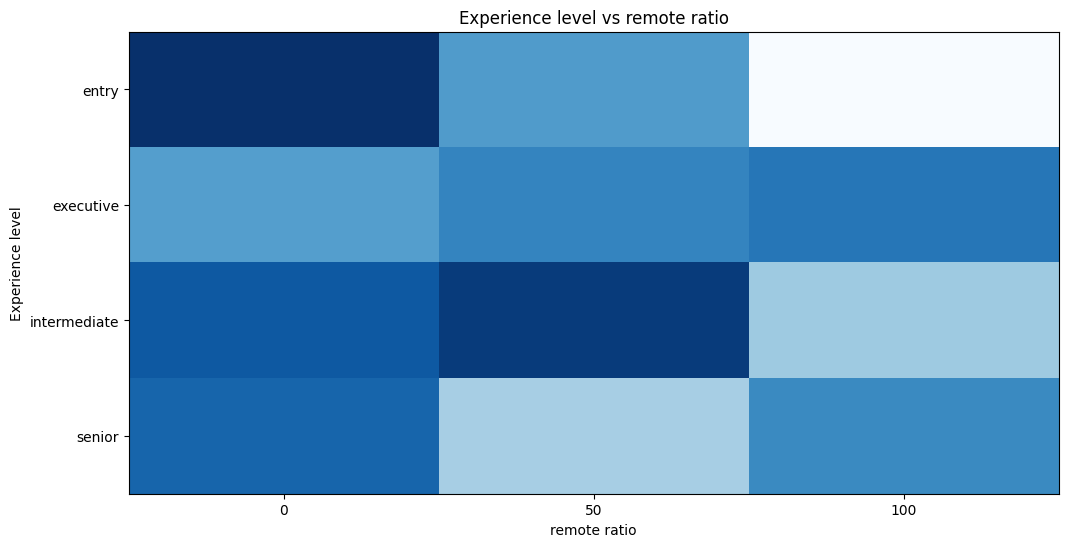

In [ ]:
df['experience_level']=df['experience_level'].replace({
    'EN':'entry',
    'MI':'intermediate',
    'SE':'senior',
    'EX':'executive'
})

import matplotlib.pyplot as plt

ct=pd.crosstab(df['experience_level'],df['remote_ratio'])

plt.figure(figsize=(12,6))
plt.imshow(ct,cmap='Blues',aspect='auto')

plt.xticks(range(len(ct.columns)),ct.columns)
plt.yticks(range(len(ct.index)),ct.index)

plt.xlabel('remote ratio')
plt.ylabel('Experience level')
plt.title('Experience level vs remote ratio')

plt.show()




The figures in heatmap indicates that at entry and at intermediate level the chances of getting a remote job is 0 and 50 respectively i.e. least.

Executive level AI jobs have maximum employees in 100 ratio category

Overall, executive and senior have more number of employees in remote jobs and so chances of getting remote jobs are high in senior and executive level



/tmp/ipykernel_654/1468796690.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


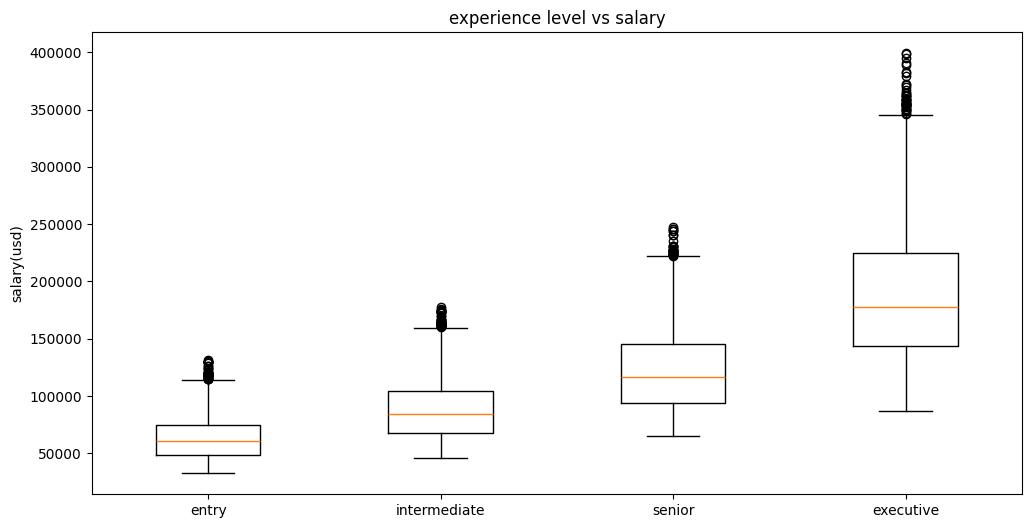

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot([
    df[df['experience_level']=='entry']['salary_usd'],
    df[df['experience_level']=='intermediate']['salary_usd'],
    df[df['experience_level']=='senior']['salary_usd'],
    df[df['experience_level']=='executive']['salary_usd']
],
   labels=['entry','intermediate','senior','executive']
)
plt.title('experience level vs salary')
plt.ylabel('salary(usd)')
plt.show()

Salary generally increases as experience level increases. Executive-level professionals have the highest median salary. Senior and Executive roles also show larger salary variation, indicating a wider range of compensation packages.

Executive categories has 1st quartile skewed median. It indicates higher salary variation in executive cateogry..

A lot of professionals in the executive categories lies in outlier and gets exceptional salaries.Outliers generally decreases as we move from executive towards entry.

/tmp/ipykernel_5012/1644068743.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


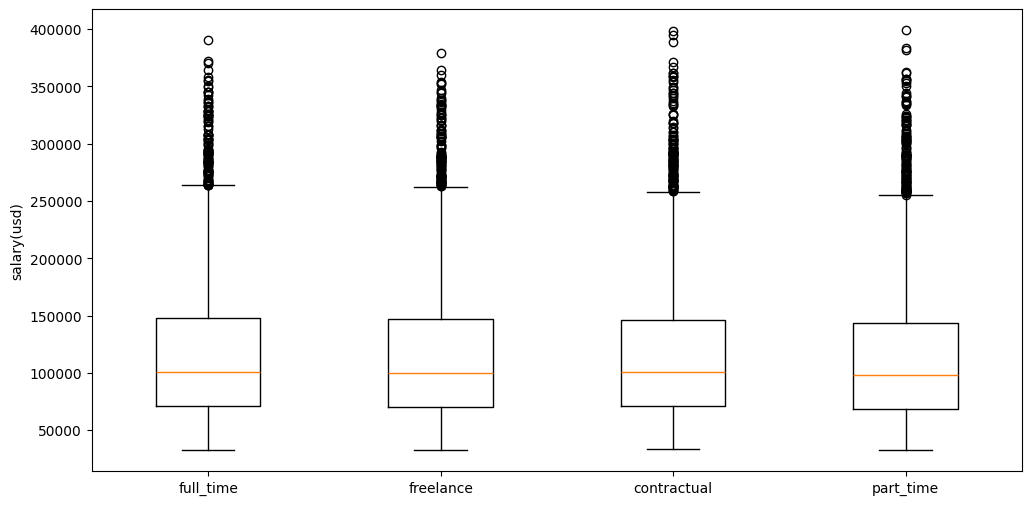

In [ ]:
df['employment_type']=df['employment_type'].replace({
    'FT':'full_time',
    'FL':'freelance',
    'CT':'contractual',
    'PT':'part_time'
})

plt.figure(figsize=(12,6))
plt.boxplot([
    df[df['employment_type']=='full_time']['salary_usd'],
    df[df['employment_type']=='freelance']['salary_usd'],
    df[df['employment_type']=='contractual']['salary_usd'],
    df[df['employment_type']=='part_time']['salary_usd']
],
    labels=['full_time','freelance','contractual','part_time']
            )
plt.title('Employment_type vs salaries(usd)')
plt.ylabel('salary(usd)')
plt.show()

The median for all employment_type comes out to be almost same. This indicates that employment_type doesn't impact salaries in AI jobs.

Outliers are similar in number in every employment_type categories...

Therefore boxplot can't distinguish much between the boxes

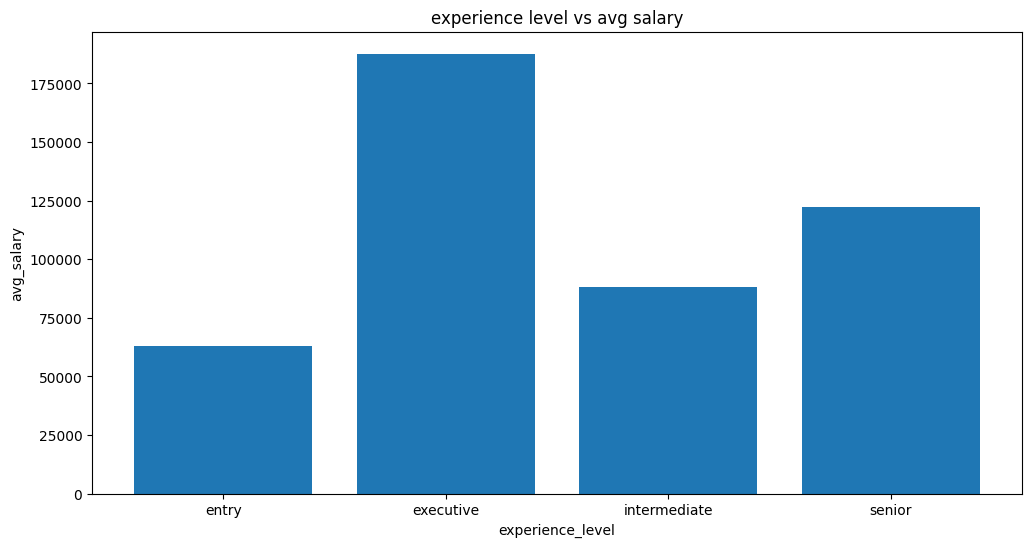

In [ ]:
avg_salary=df.groupby('experience_level')['salary_usd'].mean()
plt.figure(figsize=(12,6))
plt.bar(avg_salary.index,avg_salary.values)

plt.title('experience level vs avg salary')
plt.xlabel('experience_level')
plt.ylabel('avg_salary')


plt.show()

In boxplot we saw the median salary,variation and outliers were higher for executive which kept on decreasing with level.

Here we calculate mean value:

- avg. salary of executive category is dispropotionally higher compared to other three categories

- other three categories are some what stable

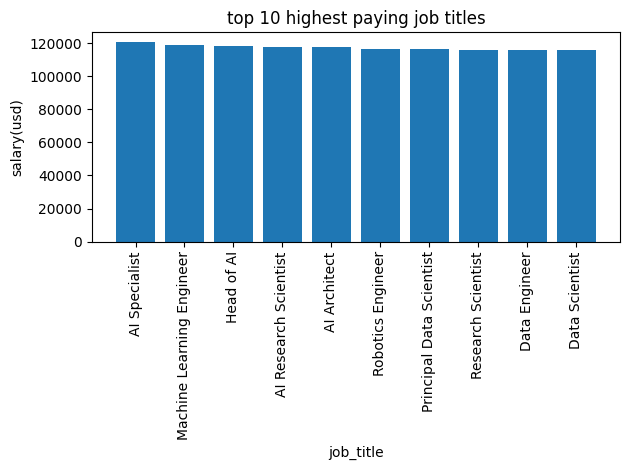

In [ ]:
counts=df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)

plt.bar(counts.index,counts.values)

plt.title('top 10 highest paying job titles')
plt.xlabel('job_title')
plt.ylabel('salary(usd)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

The figure shows avg. top 10 highest paid AI Job title.

AI specialist gets highest paid on an average

Avg. salary of various job titles is like a 100 meter race wherein AI specialist just wins.

In [ ]:
# salary prediction model
# impact ofexperience_level,company_size,company_location,remote_ratio on salary

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

x=df[['experience_level','company_size','company_location','remote_ratio']]

reciepe=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(),['experience_level','company_size','company_location']),
        ('num',StandardScaler(),['remote_ratio'])
    ]
)

# coloumn transormer used to seperate and allocate DIFFERENT transformers to both categorical and numeric coloumn present in input x


X=reciepe.fit_transform(x)
Y=df['salary_usd']

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()

model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

from sklearn.metrics import r2_score,mean_absolute_error
print('r2_score',r2_score(Y_test,Y_pred))
print('MAE',mean_absolute_error(Y_test,Y_pred))






r2_score 0.8863912598337871
MAE 14674.241097924114
